# Supplementary: Ridge regression details

| Panel | What |
|-------|------|
| A | CV R² distributions — all 5 non-HPF LFP targets, waveform-only model |
| B | Predicted vs actual — all 5 LFP targets, waveform-only model (sig cells only) |
| C | Pre vs post-spike β correlation — justifies averaging pre/post |
| D | Full beta profile — all 8 waveform features, all LFP targets |
| E | Top target × feature combos with large effect and mixed cell direction |

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from pop_ridge_utils import (
    merge_hpf_targets,
    aggregate_population,
    average_pre_post_betas,
    run_population_tests,
    run_r2_tests,
    plot_r2_summary_boxplot,
    build_population_scatter,
    plot_beta_full_summary,
    plot_beta_heterogeneity_top_combos,
    plot_beta_pre_post_scatter,
)
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
ALPHA     = 0.05
MIN_CELLS = 5

# internal keys (match target_labels after stripping Pre/Post)
ALL_FEATS_KEYS = [
    'LFP Amp', 'LFP Std', 'Exponent', 'Gamma AUC', 'Theta AUC',
]
ALL_FEATS_DISPLAY = [
    'LFP Amp', 'LFP Std', 'Aperiodic Exponent', 'Gamma AUC', 'Theta AUC',
]

In [2]:
all_results, cell_ids, target_names, target_labels, predictor_sets = merge_hpf_targets(
    RIDGE_PICKLE_DIR, FEAT_LABELS,
)

# Exclude only HPF variants — keep all non-HPF targets including LFP Amp
keep = [i for i, tl in enumerate(target_labels) if '(HPF)' not in tl]
target_names  = [target_names[i]  for i in keep]
target_labels = [target_labels[i] for i in keep]

r2_pop, sig_pop, beta_pop = aggregate_population(
    all_results, cell_ids, target_names, predictor_sets)

df_r2 = run_r2_tests(
    r2_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
sig_r2_targets = (
    df_r2[df_r2['sig_r2'] & (df_r2['predictor_set'] == 'Waveform only')]
    ['target'].tolist()
)

df_tests = run_population_tests(
    beta_pop, target_names, target_labels,
    min_cells=MIN_CELLS, alpha=ALPHA,
    sig_r2_targets=sig_r2_targets,
)

print('Significant R² targets (Waveform only):', sig_r2_targets)
print(f'Cells: {len(cell_ids)}')
print('Active targets:', target_labels)

Merged: 37 cells  |  14 targets (Pre+Post abs + HPF amp/std, no BL-corrected or Δ)
R² > 0 Wilcoxon: 30 (target × predictor_set) pairs  |  p<0.05: 9  (each target independent, no cross-target correction)
 target_label      predictor_set  n_cells  median_r2  mean_r2    p_str stars
  Pre LFP Amp      Waveform only       37   0.034011 0.077546 < 0.0001   ***
  Pre LFP Amp Waveform + Log ISI       37   0.044731 0.085571 < 0.0001   ***
  Pre LFP Std      Waveform only       37   0.005885 0.030551 < 0.0001   ***
  Pre LFP Std Waveform + Log ISI       37   0.011401 0.039090 < 0.0001   ***
 Post LFP Amp      Waveform only       37   0.027957 0.076438 < 0.0001   ***
 Post LFP Amp Waveform + Log ISI       37   0.040640 0.084664 < 0.0001   ***
 Post LFP Std      Waveform only       37   0.005119 0.028970   0.0003   ***
 Post LFP Std Waveform + Log ISI       37   0.010076 0.036655 < 0.0001   ***
Post Exponent Waveform + Log ISI       37   0.001942 0.006943   0.0228     *
Beta tests restricted to 4 

In [3]:
# Average pre+post betas (justified by Panel A: ρ ≥ 0.96 for all features)
beta_avg, avg_tns, avg_tls = average_pre_post_betas(beta_pop, target_names, target_labels)
df_tests_avg = run_population_tests(
    beta_avg, avg_tns, avg_tls,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
print('Averaged targets:', avg_tls)

Beta consistency: 40 pairs across 5 targets  |  t-test p<0.05: 3  |  Wilcoxon p<0.05: 4
target_label    feature  n  median_beta  p_str stars_wilcox
     LFP Amp   Ramp Amp 37    -0.006710 0.0323            *
     LFP Amp  Infl. Amp 37     0.013091 0.0275            *
     LFP Amp  Sharpness 37    -0.013995 0.0310            *
   Gamma AUC Peak Width 37    -0.006645 0.0455            *
Averaged targets: ['LFP Amp', 'LFP Std', 'Gamma AUC', 'Exponent', 'Theta AUC']


## Panel A — CV R² distributions (waveform-only model, all targets)

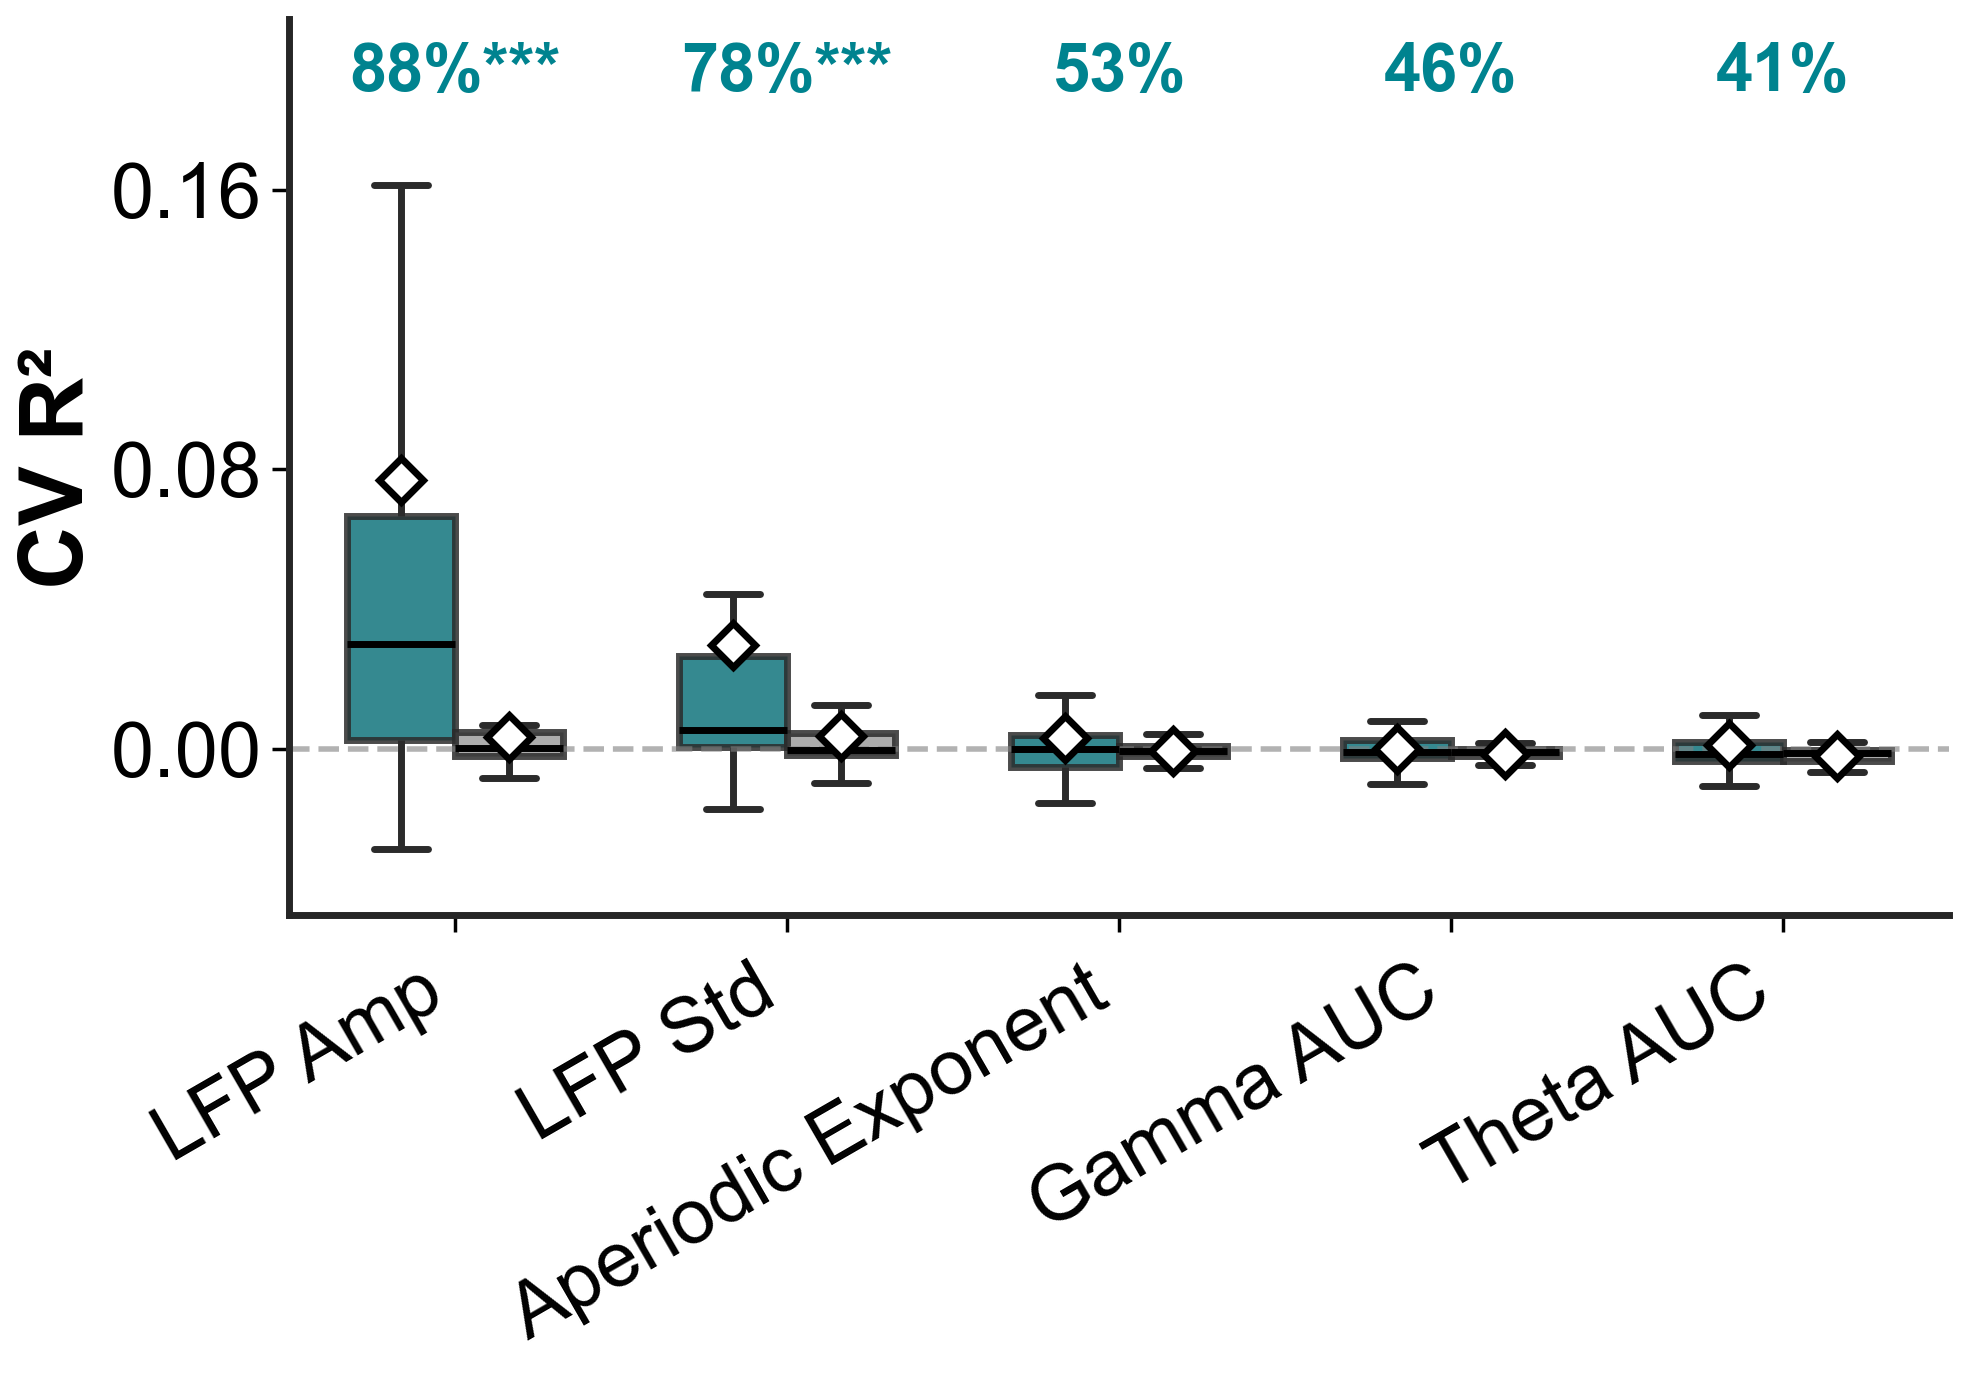

(<Figure size 1000x700 with 1 Axes>,
 array([[<Axes: ylabel='CV R²'>]], dtype=object),
 <Figure size 280x220 with 1 Axes>)

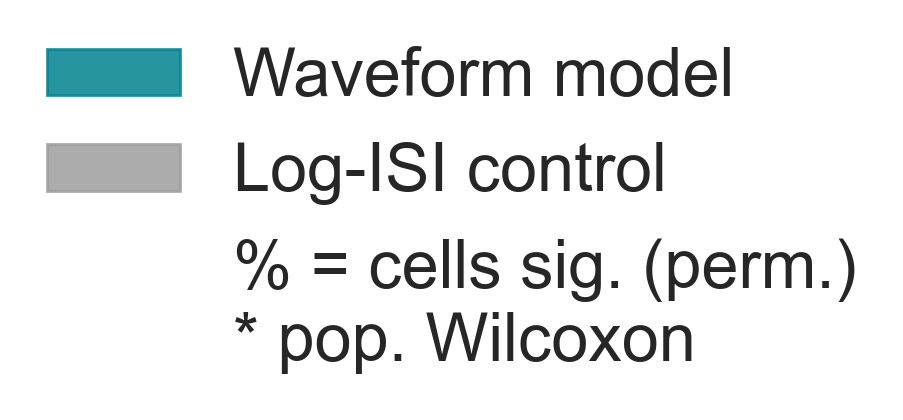

In [18]:
plot_r2_summary_boxplot(r2_pop, sig_pop, df_r2, target_names, target_labels,
                        feat_order=ALL_FEATS_KEYS,
                        feat_display_names=ALL_FEATS_DISPLAY,
                        control_predictor_set='Log ISI only',
                        combine_windows=True)

## Panel B — Predicted vs actual (all LFP targets, waveform-only model)

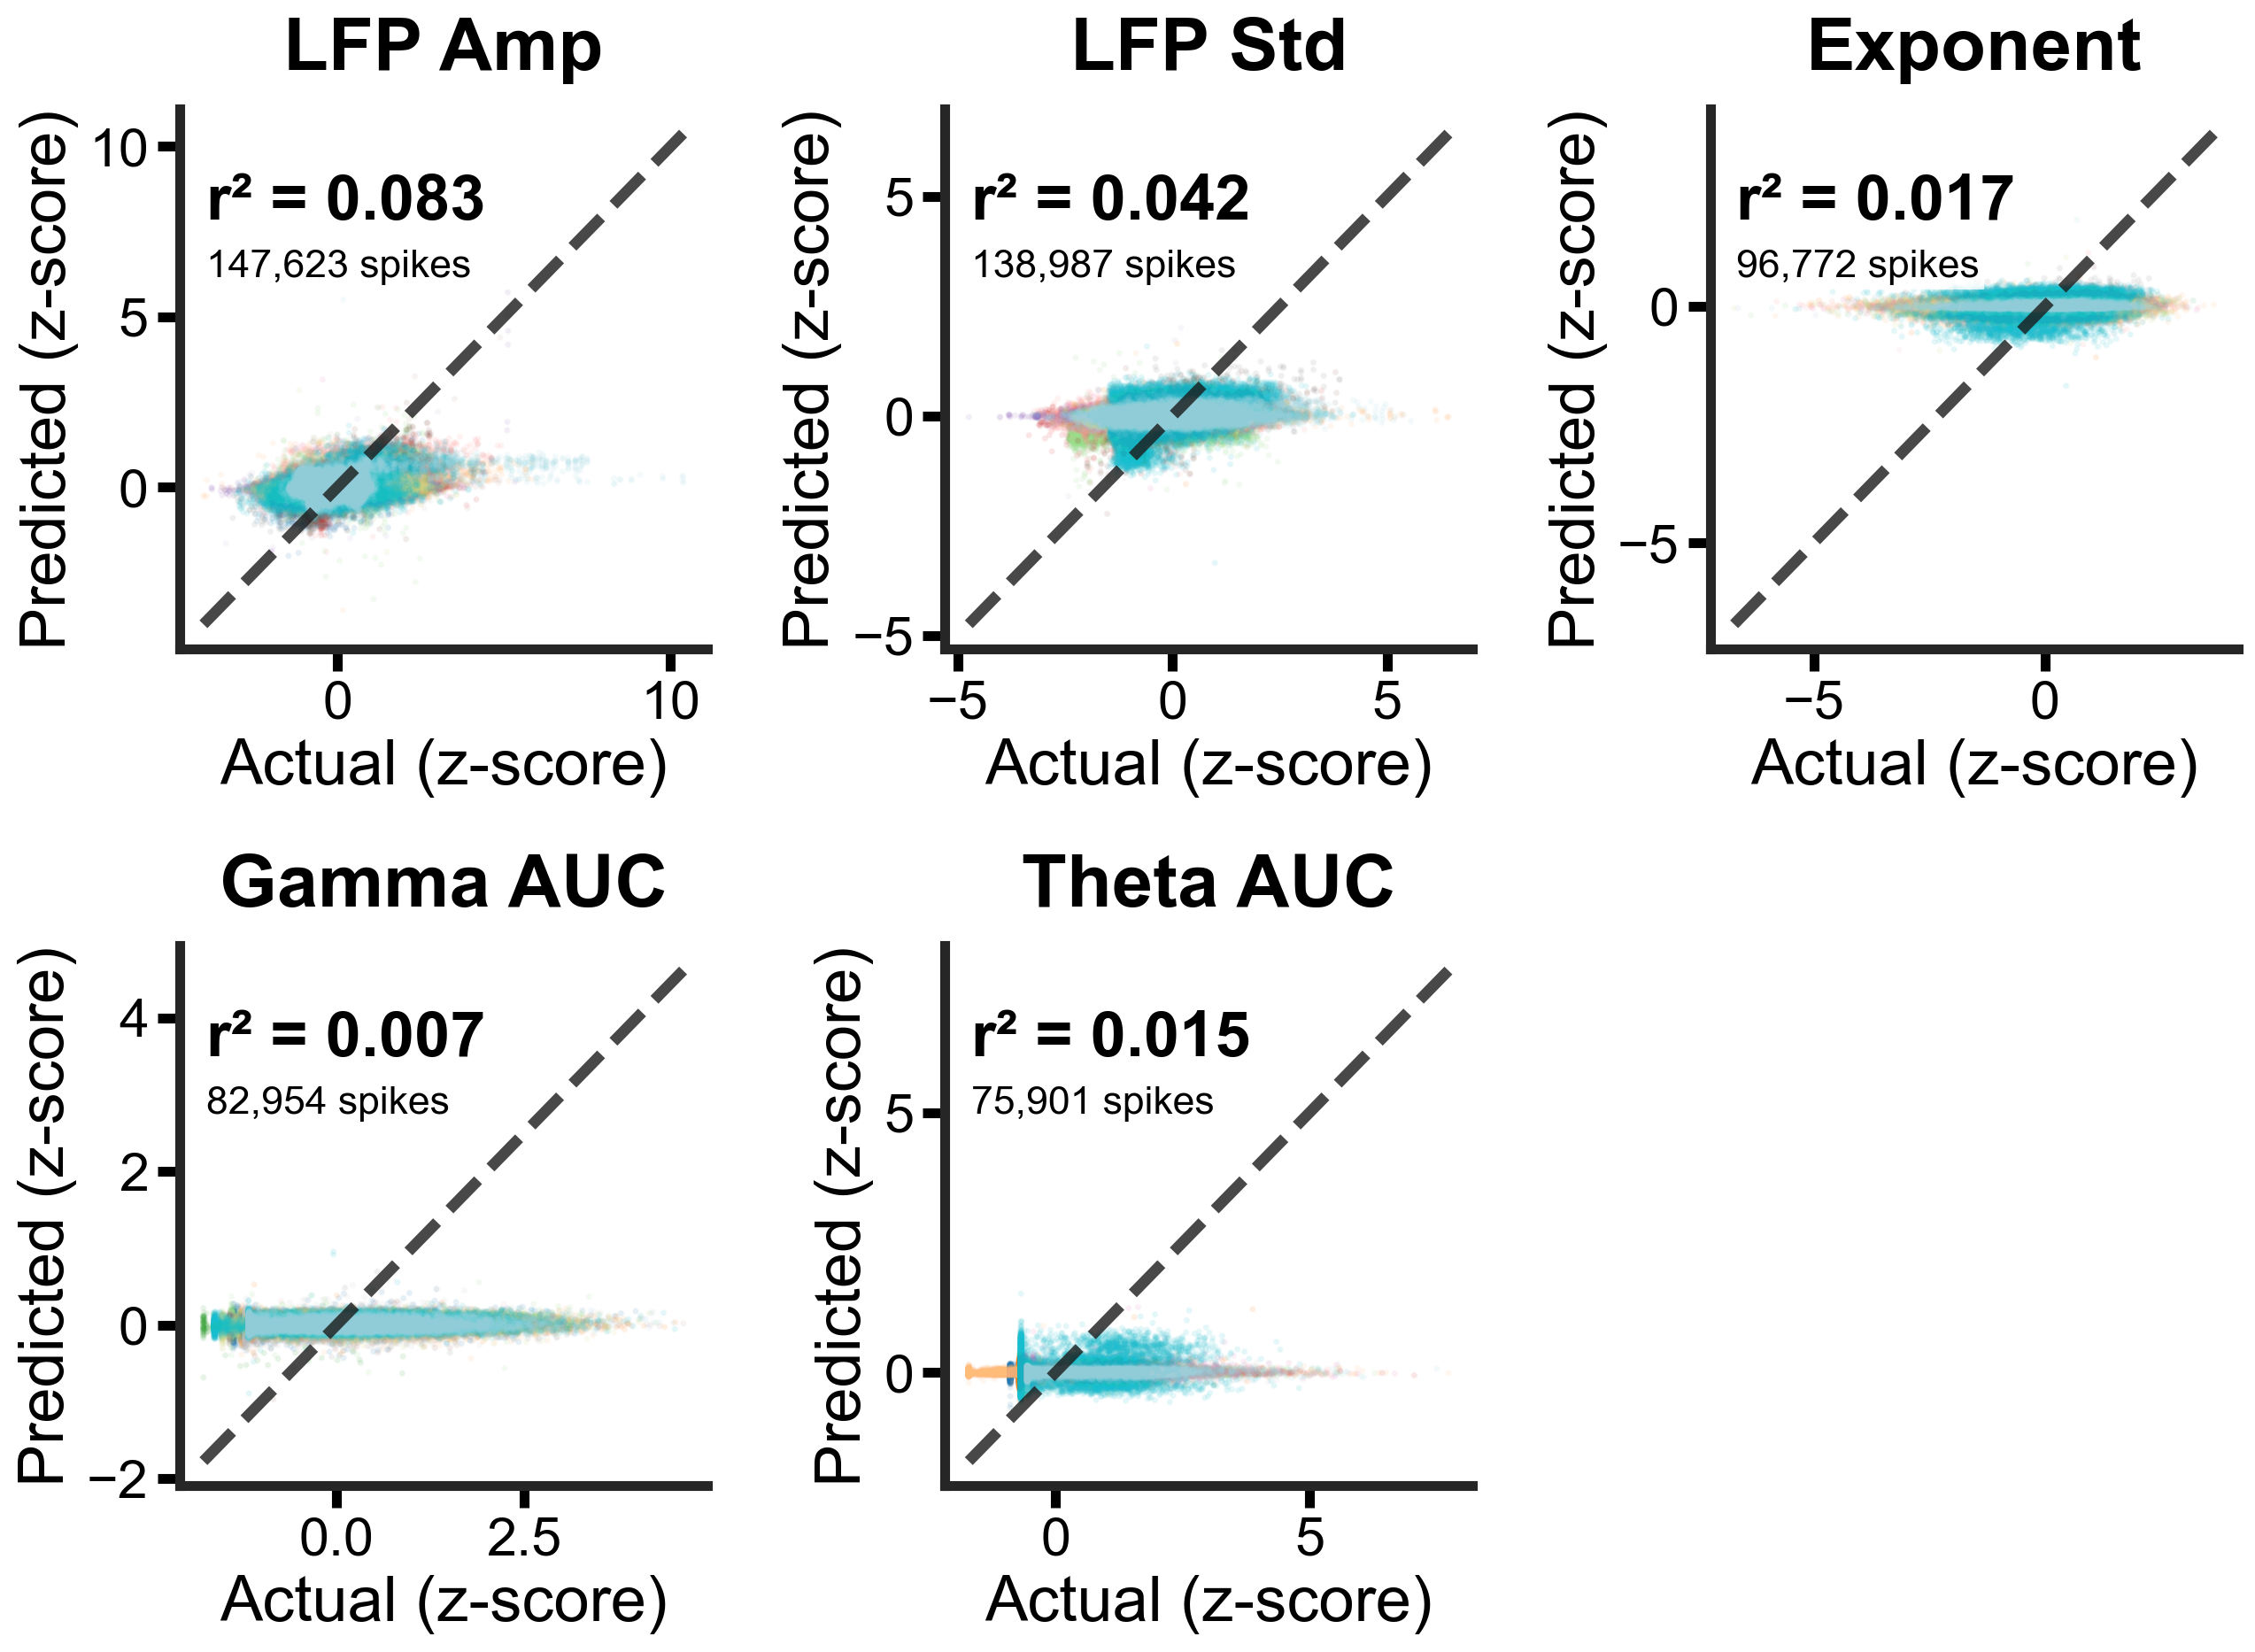

In [5]:
build_population_scatter(all_results, cell_ids, target_names, target_labels,
                         feat_order=ALL_FEATS_KEYS,
                         win_order=['Pre'])

## Panel C — Pre vs post-spike β correlation

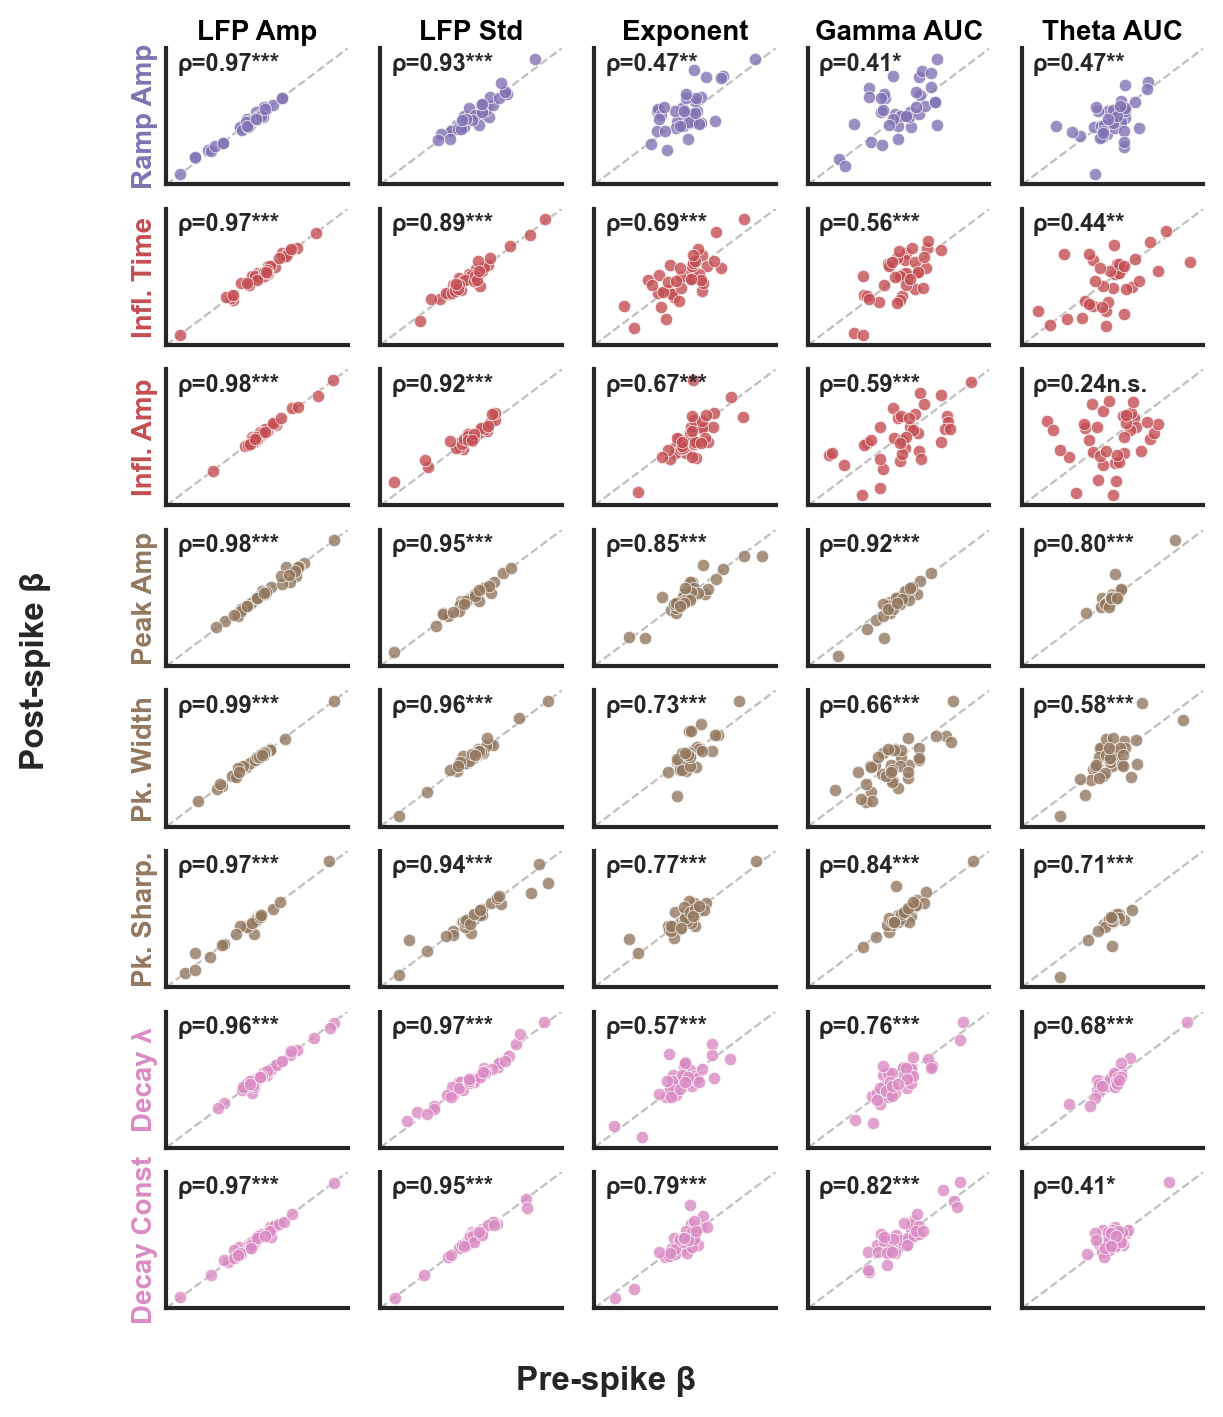

(<Figure size 610x741 with 40 Axes>,
 array([[<Axes: title={'center': 'LFP Amp'}, ylabel='Ramp Amp'>,
         <Axes: title={'center': 'LFP Std'}>,
         <Axes: title={'center': 'Exponent'}>,
         <Axes: title={'center': 'Gamma AUC'}>,
         <Axes: title={'center': 'Theta AUC'}>],
        [<Axes: ylabel='Infl. Time'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Infl. Amp'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Peak Amp'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Pk. Width'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Pk. Sharp.'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Decay λ'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Decay Const'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >]], dtype=object))

In [14]:
plot_beta_pre_post_scatter(
    beta_pop, target_names, target_labels,
    target_pairs=[
        ('Pre LFP Amp',   'Post LFP Amp'),
        ('Pre LFP Std',   'Post LFP Std'),
        ('Pre Exponent',  'Post Exponent'),
        ('Pre Gamma AUC', 'Post Gamma AUC'),
        ('Pre Theta AUC', 'Post Theta AUC'),
    ]
)

## Panel D — Full beta profile (all 8 waveform features, all R²-significant targets)

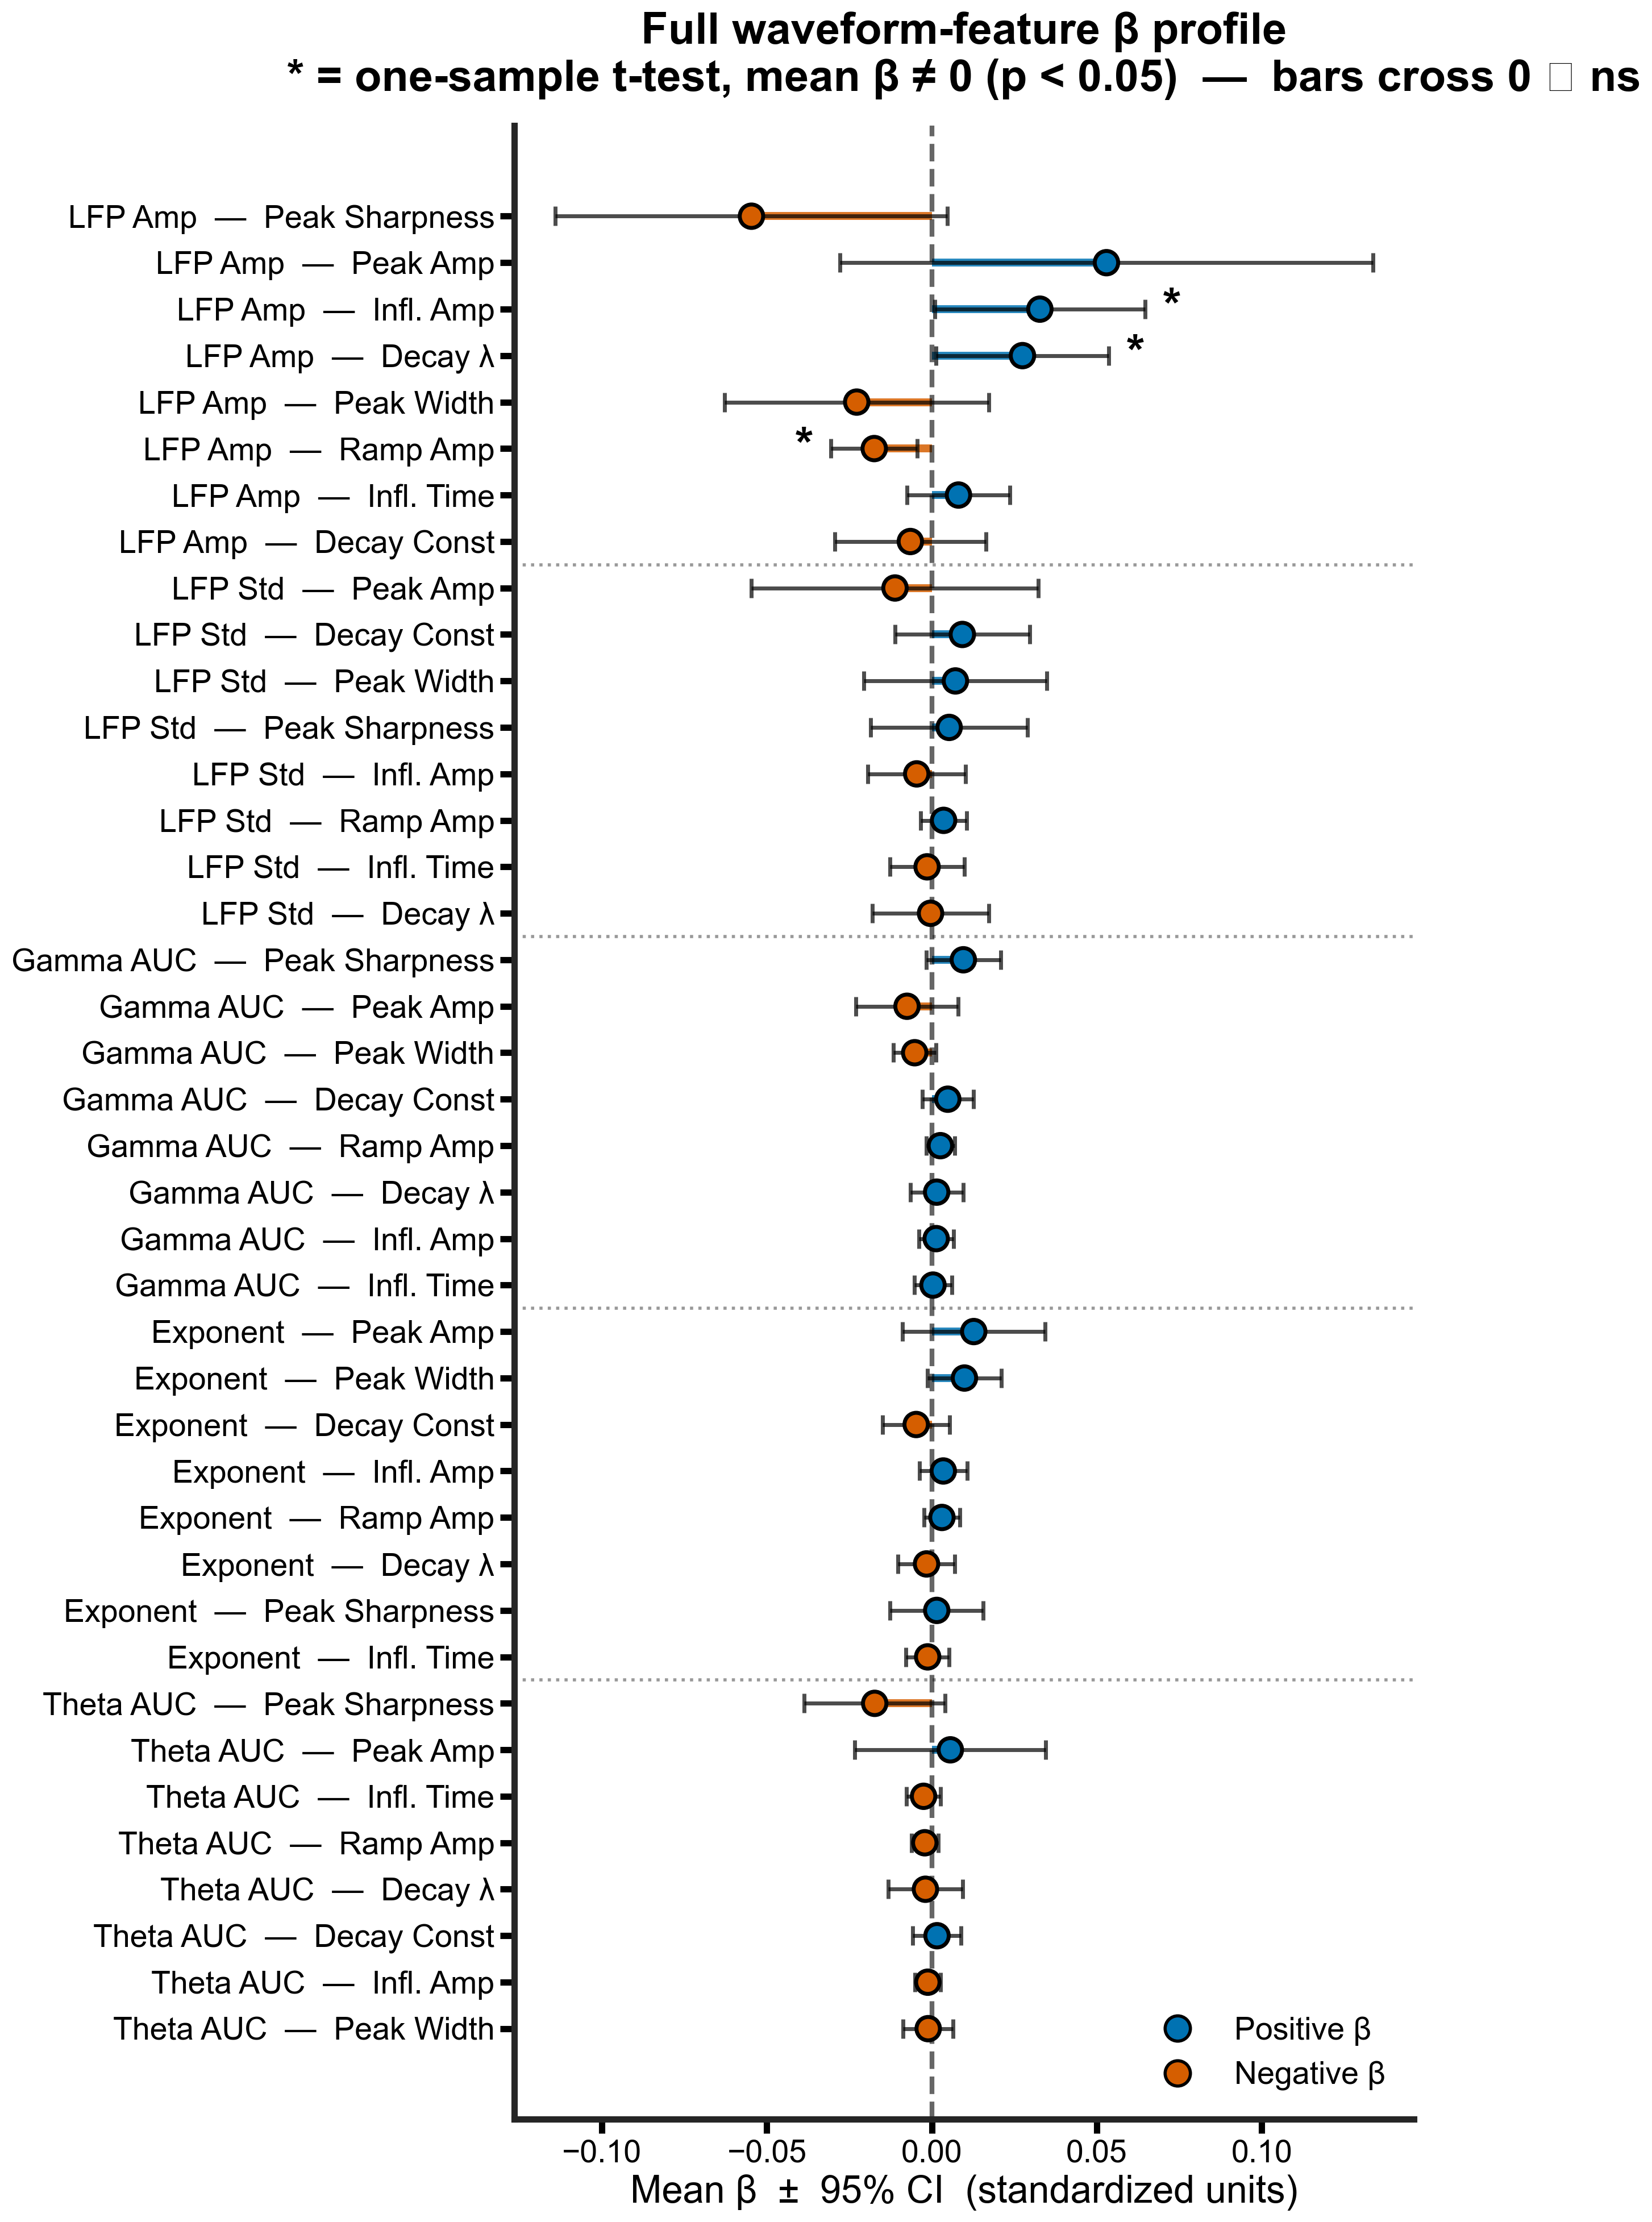

(<Figure size 1300x2000 with 1 Axes>,
 <Axes: title={'center': 'Full waveform-feature β profile\n* = one-sample t-test, mean β ≠ 0 (p < 0.05)  —  bars cross 0 ⟺ ns'}, xlabel='Mean β  ±  95% CI  (standardized units)'>)

In [7]:
plot_beta_full_summary(df_tests_avg, avg_tns, avg_tls,
                       targets=tuple(avg_tls))

---
## Figure caption (draft)

**Supplementary Figure X. Ridge regression details.**

*[Caption placeholder — fill in after reviewing output.]*

## Panel E — Top feature combos: large effect, mixed cell direction

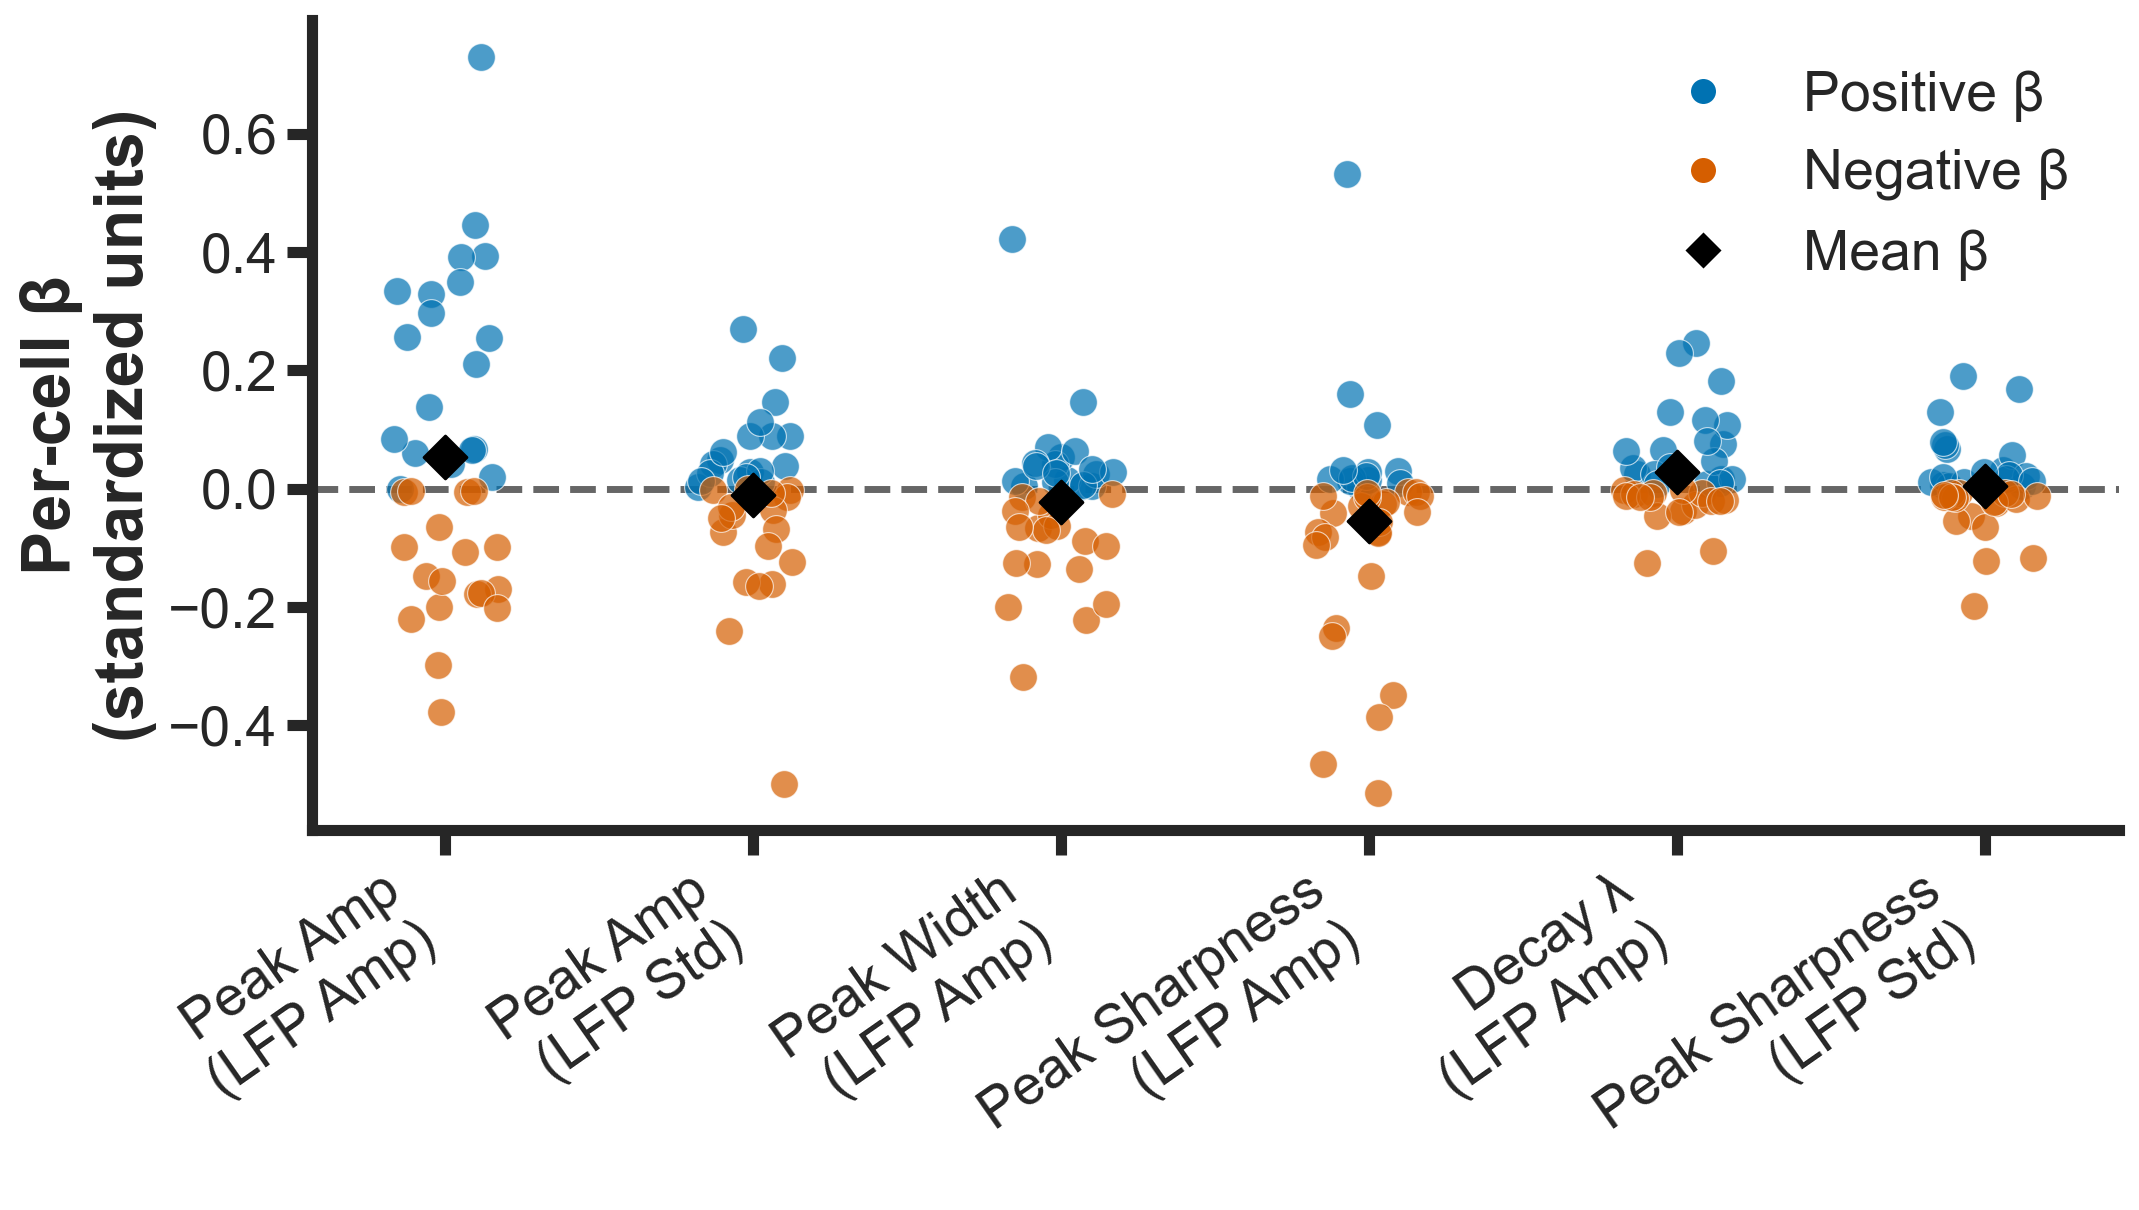

(<Figure size 1200x650 with 1 Axes>,
 <Axes: ylabel='Per-cell β\n(standardized units)'>)

In [8]:
plot_beta_heterogeneity_top_combos(
    beta_avg, avg_tns, avg_tls,
    n_top=6,
)
